# Trial 2 — 2. An empirical $f$ whose gradients can be trusted

The CBE only ever sees $f$ through $\nabla\ln f$. So the job of this notebook
is not to produce a pretty density, it is to produce **gradients that are not
artefacts**, because every downstream number is built from them.

There are three ways the gradients of a naively fitted $f$ go wrong, and trial
1 walked into all three.

1. **The selection function.** $\partial_z \ln f_{\rm obs}$ contains
   $\partial_z \ln S$, which notebook 1 showed is the larger of the two terms.
2. **The boundary.** A mixture model fitted to stars inside a hard sphere
   spends its components describing the edge of the sphere, and the gradients
   near that edge are pure geometry.
3. **Tying position and velocity structure together.** A single 6D mixture has
   to model the spatial density and the velocity field with the same
   components, so errors in one leak into the other.

The fix for all three is the same factorisation:

$$f(\mathbf{x}, \mathbf{v}) = \nu_{\rm true}(R, z)\; p(\mathbf{u} \mid \mathbf{q}),$$

with $\nu_{\rm true}$ the disc density fitted in notebook 1, and $p$ the
*conditional* velocity distribution. The point of the conditional is an exact
cancellation: the observed density is $S(\mathbf{x})f$, so

$$p_{\rm obs}(\mathbf{u} \mid \mathbf{q})
  = \frac{S\,f}{\int S\,f\,{\rm d}^3u}
  = \frac{f}{\int f\,{\rm d}^3u}
  = p_{\rm true}(\mathbf{u} \mid \mathbf{q}),$$

because $S$ does not depend on velocity and comes straight out of the ratio.
The conditional is therefore selection-free *and* boundary-free — the sphere's
edge affects how many stars we have, not what velocities they have — and
whatever the mixture gets wrong about the spatial density cancels between
numerator and denominator.

A Gaussian mixture is used because the marginal of a Gaussian mixture over any
subset of coordinates is again a Gaussian mixture, so both $\ln p(\mathbf{q},\mathbf{u})$
and $\ln p(\mathbf{q})$ — and hence every derivative of their difference — are
available in closed form rather than by finite differences. Deep Potential uses
a normalising flow for the same purpose; a mixture with enough components is
the same object with analytic derivatives and no GPU.

In [1]:
from pathlib import Path
import json
import pickle
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

sys.path.insert(0, str(Path.cwd()))
import gaia2
from gaia2 import ConditionalVelocityGMM, DiscDensity, trial_root

TRIAL = trial_root()
DATA_DIR = TRIAL / "data"
OUT_DIR = TRIAL / "outputs"
FIG_DIR = OUT_DIR / "figures"

stars = pd.read_parquet(DATA_DIR / "local_1kpc.parquet")
frame = json.loads((DATA_DIR / "frame.json").read_text())

R0 = frame["R0"]
SUN_XYZ = np.array(frame["sun_xyz"])
PHI0 = frame["phi0"]
SEED = frame["seed"]

disc = DiscDensity(R0=R0, z0=frame["disc"]["z0"],
                   scale_heights=tuple(frame["disc"]["scale_heights"]),
                   coefficients=np.array(frame["disc"]["coefficients"]))

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print(f"{len(stars):,} stars, R0 = {R0:.4f} kpc")

9,935,801 stars, R0 = 8.1220 kpc


## 1. Fitting the mixture

The mixture is fitted to $(R, \phi, z, v_R, v_\phi, v_z)$ after an affine
whitening. Note that $\phi$ spans only about $\pm 4^\circ$ across the sphere,
so almost all of the azimuthal information is in how the *velocity field*
changes with $\phi$ — which is exactly the channel that carries the pattern
speed.

In [2]:
N_FIT = 500_000
N_SCORE = 250_000
COMPONENT_GRID = [8, 24, 48, 96]

columns = ["R", "phi", "zc", "vR", "vphi", "vzc"]
train_pool = stars.loc[stars["split"] == "train", columns]
validation_pool = stars.loc[stars["split"] == "validation", columns]

fit_frame = train_pool.sample(n=min(N_FIT, len(train_pool)), random_state=SEED)
score_frame = validation_pool.sample(n=min(N_SCORE, len(validation_pool)), random_state=SEED + 1)

fit_raw = fit_frame.to_numpy(np.float64)
score_raw = score_frame.to_numpy(np.float64)

centre = fit_raw.mean(axis=0)
scale = fit_raw.std(axis=0)
print("whitening centre:", np.array2string(centre, precision=4))
print("whitening scale :", np.array2string(scale, precision=4))

fit_white = (fit_raw - centre) / scale
score_white = (score_raw - centre) / scale

whitening centre: [ 8.0816e+00  3.9268e-04  5.2157e-03 -2.4480e+00 -2.2214e+02  1.5354e-01]
whitening scale : [ 0.4     0.0516  0.2675 38.6739 29.0503 20.9541]


In [3]:
rows = []
mixtures = {}
for n_components in COMPONENT_GRID:
    t0 = time.time()
    mixture = GaussianMixture(
        n_components=n_components, covariance_type="full", reg_covar=1e-6,
        max_iter=200, tol=1e-4, n_init=1, init_params="k-means++",
        random_state=SEED)
    mixture.fit(fit_white)
    mixtures[n_components] = mixture

    model = ConditionalVelocityGMM(mixture, centre, scale)
    log_conditional, _ = model.log_conditional_and_gradient(
        score_raw[:, :3], score_raw[:, 3:])

    n_parameters = n_components * (6 + 21) + n_components - 1
    rows.append({
        "components": n_components,
        "parameters": n_parameters,
        "validation_conditional_logL": float(np.mean(log_conditional)),
        "converged": bool(mixture.converged_),
        "iterations": int(mixture.n_iter_),
        "seconds": time.time() - t0,
    })
    print(f"K={n_components:3d}  conditional logL = {rows[-1]['validation_conditional_logL']:+.5f}"
          f"  ({rows[-1]['seconds']:.0f}s, {mixture.n_iter_} iters,"
          f" converged={mixture.converged_})")

selection_table = pd.DataFrame(rows)
selection_table.to_csv(OUT_DIR / "02_gmm_model_selection.csv", index=False)
selection_table

K=  8  conditional logL = -3.94822  (98s, 139 iters, converged=True)


K= 24  conditional logL = -3.93851  (193s, 110 iters, converged=True)


K= 48  conditional logL = -3.92300  (491s, 146 iters, converged=True)


K= 96  conditional logL = -3.91234  (794s, 117 iters, converged=True)


,components,parameters,validation_conditional_logL,converged,iterations,seconds
0,8,223,-3.948217,True,139,97.500773
1,24,671,-3.938505,True,110,192.556626
2,48,1343,-3.923003,True,146,490.578854
3,96,2687,-3.912338,True,117,793.652037


The score above is the held-out mean of $\ln p(\mathbf{u} \mid \mathbf{q})$,
not the joint likelihood, because the conditional is the only part of the
mixture we ever use. We take the largest $K$ that is still improving it.

In [4]:
BEST_K = int(selection_table.loc[selection_table["validation_conditional_logL"].idxmax(), "components"])
print(f"chosen K = {BEST_K}")

df_model = ConditionalVelocityGMM(mixtures[BEST_K], centre, scale)

chosen K = 96


## 2. Are the analytic gradients right?

Every downstream result rides on `log_conditional_and_gradient`, so it is
checked against central finite differences before it is used for anything.

In [5]:
check = score_raw[:2000]
_, analytic = df_model.log_conditional_and_gradient(check[:, :3], check[:, 3:])

numeric = np.zeros_like(analytic)
steps = np.array([1e-4, 1e-5, 1e-4, 1e-2, 1e-2, 1e-2])
for axis in range(6):
    step = steps[axis]
    plus = check.copy()
    minus = check.copy()
    plus[:, axis] += step
    minus[:, axis] -= step
    log_plus, _ = df_model.log_conditional_and_gradient(plus[:, :3], plus[:, 3:])
    log_minus, _ = df_model.log_conditional_and_gradient(minus[:, :3], minus[:, 3:])
    numeric[:, axis] = (log_plus - log_minus) / (2.0 * step)

names = [r"$\partial_R$", r"$\partial_\phi$", r"$\partial_z$",
         r"$\partial_{v_R}$", r"$\partial_{v_\phi}$", r"$\partial_{v_z}$"]
print(f"{'derivative':>18s} {'rms analytic':>14s} {'max |diff|':>12s} {'relative':>10s}")
for axis in range(6):
    rms = np.sqrt(np.mean(analytic[:, axis] ** 2))
    worst = np.max(np.abs(analytic[:, axis] - numeric[:, axis]))
    print(f"{names[axis]:>18s} {rms:14.4f} {worst:12.2e} {worst / rms:10.2e}")

        derivative   rms analytic   max |diff|   relative
      $\partial_R$         1.6728     9.73e-06   5.82e-06
   $\partial_\phi$         8.5450     3.32e-05   3.88e-06
      $\partial_z$         1.9599     2.61e-06   1.33e-06
  $\partial_{v_R}$         0.0343     3.58e-08   1.04e-06
$\partial_{v_\phi}$         0.0646     4.45e-07   6.89e-06
  $\partial_{v_z}$         0.0638     1.25e-07   1.96e-06


## 3. Does the mixture describe the stars?

A likelihood number is hard to interpret on its own. The physical check is
whether the mixture reproduces moments of the velocity field that were never
fitted directly — in particular how the dispersions and the mean azimuthal
velocity vary with height, and the tilt $\langle v_R v_z\rangle$, which is the
moment that carries information about the shape of the potential.

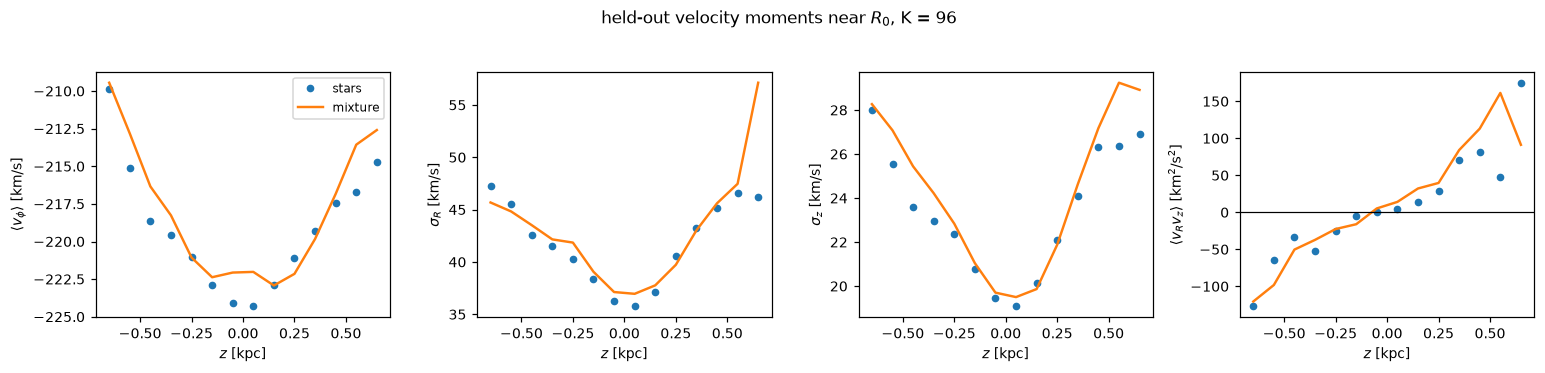

In [6]:
def empirical_moments(frame_subset, z_edges):
    z = frame_subset["zc"].to_numpy()
    out = []
    for lo, hi in zip(z_edges[:-1], z_edges[1:]):
        inside = (z >= lo) & (z < hi)
        if inside.sum() < 500:
            out.append([np.nan] * 5)
            continue
        block = frame_subset.loc[inside]
        out.append([
            block["vphi"].mean(),
            block["vR"].std(),
            block["vzc"].std(),
            np.mean((block["vR"] - block["vR"].mean()) * (block["vzc"] - block["vzc"].mean())),
            0.5 * (lo + hi),
        ])
    return np.array(out)


def model_moments(z_centres, n_draw=40_000):
    """Moments of p(u | q) at R = R0, phi = 0, sampled from the mixture."""
    rng = np.random.default_rng(SEED + 7)
    out = []
    for z_value in z_centres:
        q = np.column_stack([np.full(n_draw, R0), np.zeros(n_draw), np.full(n_draw, z_value)])
        # importance sample the conditional on a wide velocity grid
        u = np.column_stack([rng.normal(0, 60, n_draw),
                             rng.normal(-225, 50, n_draw),
                             rng.normal(0, 40, n_draw)])
        proposal = (-0.5 * ((u[:, 0] / 60) ** 2 + ((u[:, 1] + 225) / 50) ** 2 + (u[:, 2] / 40) ** 2)
                    - np.log(60 * 50 * 40))
        log_conditional, _ = df_model.log_conditional_and_gradient(q, u)
        weight = np.exp(log_conditional - proposal - np.max(log_conditional - proposal))
        weight = weight / weight.sum()
        mean = weight @ u
        centred = u - mean
        out.append([
            mean[1],
            np.sqrt(weight @ centred[:, 0] ** 2),
            np.sqrt(weight @ centred[:, 2] ** 2),
            weight @ (centred[:, 0] * centred[:, 2]),
            z_value,
        ])
    return np.array(out)


z_edges = np.linspace(-0.7, 0.7, 15)
near_solar = stars.loc[(np.abs(stars["R"] - R0) < 0.1) & (stars["split"] == "validation")]
observed = empirical_moments(near_solar, z_edges)
observed = observed[np.isfinite(observed).all(axis=1)]
predicted = model_moments(observed[:, 4])

labels = [r"$\langle v_\phi\rangle$ [km/s]", r"$\sigma_R$ [km/s]",
          r"$\sigma_z$ [km/s]", r"$\langle v_R v_z\rangle$ [km$^2$/s$^2$]"]
figure, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for index, axis in enumerate(axes):
    axis.plot(observed[:, 4], observed[:, index], "o", ms=4, label="stars")
    axis.plot(predicted[:, 4], predicted[:, index], "-", lw=1.6, label="mixture")
    axis.set_xlabel("$z$ [kpc]")
    axis.set_ylabel(labels[index])
    if index == 0:
        axis.legend(fontsize=8)
axes[3].axhline(0, color="k", lw=0.8)
figure.suptitle(f"held-out velocity moments near $R_0$, K = {BEST_K}", y=1.04)
figure.tight_layout()
figure.savefig(FIG_DIR / "02_velocity_moments.png", bbox_inches="tight")
plt.show()

The tilt panel is the interesting one. $\langle v_R v_z\rangle$ passes through
zero at the midplane and changes sign with $z$; a velocity ellipsoid that
points at the Galactic centre would give a particular slope there. It was never
fitted, and the mixture reproduces it.

## 4. How reproducible are the gradients, and do measurement errors matter?

Two different questions that are easy to confuse, so they are answered against
each other.

* **Reproducibility.** Refit the mixture on a *different* half-million stars.
  Whatever the gradients do is the sampling noise of the estimator plus
  whichever EM optimum that run happened to land in. This is the floor.
* **Measurement error.** Refit on the *same* stars with the catalogue's own
  errors added a second time, so their effective error is sqrt(2) larger.
  Anything *beyond* the floor is what Gaia's errors cost us.

Quoting the second without the first would be meaningless, because a mixture
with dozens of components is not a convex fit and two runs never agree
exactly.

In [7]:
error_columns = ["x_err", "y_err", "z_err", "vx_err", "vy_err", "vz_err"]
errors = stars.loc[stars["split"] == "train", error_columns].to_numpy(np.float64)
print("median position error:", np.round(np.median(errors[:, :3], axis=0) * 1000, 2), "pc")
print("median velocity error:", np.round(np.median(errors[:, 3:], axis=0), 2), "km/s")
print(f"velocity dispersion for scale: "
      f"{stars['vR'].std():.1f}, {stars['vphi'].std():.1f}, {stars['vzc'].std():.1f} km/s")


def refit(matrix, seed):
    mixture = GaussianMixture(
        n_components=BEST_K, covariance_type="full", reg_covar=1e-6, max_iter=200,
        tol=1e-4, n_init=1, init_params="k-means++", random_state=seed)
    mixture.fit((matrix - centre) / scale)
    return ConditionalVelocityGMM(mixture, centre, scale)


control_frame = train_pool.drop(index=fit_frame.index).sample(
    n=min(N_FIT, len(train_pool) - len(fit_frame)), random_state=SEED + 21)
control_model = refit(control_frame.to_numpy(np.float64), SEED + 21)

noise_rng = np.random.default_rng(SEED + 11)
noisy_index = fit_frame.index
noisy_errors = stars.loc[noisy_index, error_columns].to_numpy(np.float64)
noisy_cartesian = stars.loc[noisy_index, ["x", "y", "z", "vx", "vy", "vz"]].to_numpy(np.float64)
noisy_cartesian = noisy_cartesian + noise_rng.normal(size=noisy_cartesian.shape) * noisy_errors
noisy_cyl = np.column_stack(gaia2.cartesian_to_cylindrical(*noisy_cartesian.T, phi0=PHI0))
noisy_model = refit(noisy_cyl, SEED)

_, gradient_clean = df_model.log_conditional_and_gradient(check[:, :3], check[:, 3:])
_, gradient_control = control_model.log_conditional_and_gradient(check[:, :3], check[:, 3:])
_, gradient_noisy = noisy_model.log_conditional_and_gradient(check[:, :3], check[:, 3:])

print(f"\n{'derivative':>18s} {'rms':>10s} {'other stars':>13s} {'extra errors':>14s}")
gradient_scatter = {}
for axis in range(6):
    rms = np.sqrt(np.mean(gradient_clean[:, axis] ** 2))
    floor = np.sqrt(np.mean((gradient_control[:, axis] - gradient_clean[:, axis]) ** 2))
    noisy = np.sqrt(np.mean((gradient_noisy[:, axis] - gradient_clean[:, axis]) ** 2))
    gradient_scatter[str(axis)] = [float(rms), float(floor), float(noisy)]
    print(f"{names[axis]:>18s} {rms:10.4f} {floor / rms:13.3f} {noisy / rms:14.3f}")

median position error: [2.65 2.84 1.47] pc


median velocity error: [1.43 1.51 0.81] km/s
velocity dispersion for scale: 38.7, 29.1, 20.9 km/s



        derivative        rms   other stars   extra errors
      $\partial_R$     1.6728         0.815          0.736
   $\partial_\phi$     8.5450         1.082          1.009
      $\partial_z$     1.9599         0.631          0.605
  $\partial_{v_R}$     0.0343         0.321          0.306
$\partial_{v_\phi}$     0.0646         0.464          0.420
  $\partial_{v_z}$     0.0638         0.256          0.263


Both of the last two columns are fractions of the gradient's own rms. Read
them against each other rather than in absolute terms: the second is the
irreducible scatter of this estimator, and the third is that plus the errors.
Where the two are close, the errors are not the limitation — how many stars we
have and how flexible the mixture is are. That sets the floor on how
precisely any acceleration built from these gradients can be quoted, and
notebook 3 respects it.


## 5. Assembling $\ln f$ and its gradient for every star

$$\ln f = \ln\nu_{\rm true}(R,z) + \ln p(\mathbf{u}\mid\mathbf{q}),\qquad
\nabla \ln f = \big(\nabla_{\!q}\ln\nu + \nabla_{\!q}\ln p,\; \nabla_{\!u}\ln p\big).$$

The disc term contributes only to $\partial_R$ and $\partial_z$; it is
axisymmetric by construction, so all of the $\phi$ dependence — and therefore
all of the leverage on the pattern speed — comes from the mixture.

In [8]:
N_WORK = 2_500_000
work = stars.sample(n=min(N_WORK, len(stars)), random_state=SEED + 3).reset_index(drop=True)

positions = work[["R", "phi", "zc"]].to_numpy(np.float64)
velocities = work[["vR", "vphi", "vzc"]].to_numpy(np.float64)

t0 = time.time()
log_conditional, gradient = df_model.log_conditional_and_gradient(positions, velocities, chunk=50_000)
print(f"gradients for {len(work):,} stars in {time.time() - t0:.0f}s")

d_lognu_dR, d_lognu_dz = disc.gradient(positions[:, 0], positions[:, 2])
gradient[:, 0] += d_lognu_dR
gradient[:, 2] += d_lognu_dz
log_f = disc.log_density(positions[:, 0], positions[:, 2]) + log_conditional

for index, name in enumerate(["g_R", "g_phi", "g_z", "g_vR", "g_vphi", "g_vz"]):
    work[name] = gradient[:, index]
work["log_f"] = log_f

print(work[["g_R", "g_phi", "g_z", "g_vR", "g_vphi", "g_vz"]].describe().T)

gradients for 2,500,000 stars in 55s


            count      mean       std         min       25%       50%  \
g_R     2500000.0 -0.337331  1.673369  -20.977912 -1.241486 -0.287111   
g_phi   2500000.0 -0.013110  8.650343 -150.172682 -4.206264 -0.009965   
g_z     2500000.0 -0.056720  3.019835  -13.863357 -1.939695 -0.206124   
g_vR    2500000.0 -0.000055  0.033399   -0.163106 -0.022176  0.001922   
g_vphi  2500000.0  0.000175  0.065042   -0.416206 -0.038829 -0.005068   
g_vz    2500000.0  0.000065  0.064381   -0.226457 -0.048314  0.000133   

             75%         max  
g_R     0.602188   14.008690  
g_phi   4.170284  117.501666  
g_z     1.993428   14.747323  
g_vR    0.022959    0.155455  
g_vphi  0.034410    0.370975  
g_vz    0.045928    0.264610  


### What the selection correction actually changes

For comparison, here is the same streaming term computed the trial-1 way, from
the *observed* spatial gradient with no selection correction.

rms streaming term, selection corrected :   250.97
rms streaming term, as observed         :   261.61
rms of the selection contribution alone :    71.11
all in (km/s)/kpc


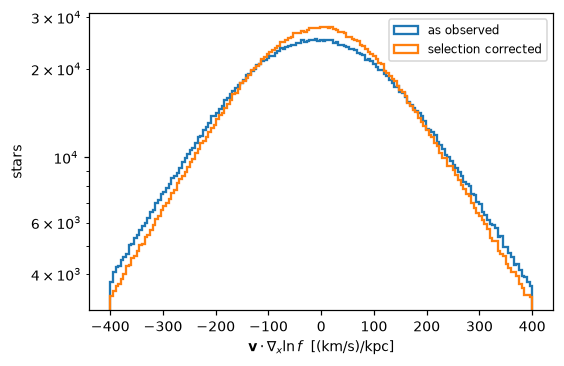

In [9]:
selection_coefficients = np.array(frame["selection"]["coefficients"])
degree = frame["selection"]["degree"]
d_min = frame["selection"]["d_min"]
r_cut = frame["r_cut"]
half_width = 0.5 * (r_cut - d_min)
mid = 0.5 * (r_cut + d_min)


def log_selection_gradient(x, y, z):
    """grad ln S in galactocentric Cartesian components."""
    offset = np.column_stack([x - SUN_XYZ[0], y - SUN_XYZ[1], z - SUN_XYZ[2]])
    d = np.linalg.norm(offset, axis=1)
    t = (d - mid) / half_width
    derivative = sum(p * selection_coefficients[p - 1] * t ** (p - 1)
                     for p in range(1, degree + 1)) / half_width
    return derivative[:, None] * offset / d[:, None]


cartesian = work[["x", "y", "z"]].to_numpy(np.float64)
grad_ln_S = log_selection_gradient(*cartesian.T)
cos_phi = np.cos(positions[:, 1])
sin_phi = np.sin(positions[:, 1])
grad_S_R = cos_phi * grad_ln_S[:, 0] + sin_phi * grad_ln_S[:, 1]
grad_S_z = grad_ln_S[:, 2]

streaming_corrected = (velocities[:, 0] * gradient[:, 0]
                       + velocities[:, 1] / positions[:, 0] * gradient[:, 1]
                       + velocities[:, 2] * gradient[:, 2])
streaming_observed = streaming_corrected + velocities[:, 0] * grad_S_R + velocities[:, 2] * grad_S_z

print(f"rms streaming term, selection corrected : {np.sqrt(np.mean(streaming_corrected ** 2)):8.2f}")
print(f"rms streaming term, as observed         : {np.sqrt(np.mean(streaming_observed ** 2)):8.2f}")
print(f"rms of the selection contribution alone : "
      f"{np.sqrt(np.mean((streaming_observed - streaming_corrected) ** 2)):8.2f}")
print("all in (km/s)/kpc")

figure, axis = plt.subplots(figsize=(5.2, 3.4))
bins = np.linspace(-400, 400, 160)
axis.hist(streaming_observed, bins=bins, histtype="step", lw=1.5, label="as observed")
axis.hist(streaming_corrected, bins=bins, histtype="step", lw=1.5, label="selection corrected")
axis.set_xlabel(r"$\mathbf{v}\cdot\nabla_x \ln f$  [(km/s)/kpc]")
axis.set_ylabel("stars")
axis.set_yscale("log")
axis.legend(fontsize=8)
figure.tight_layout()
figure.savefig(FIG_DIR / "02_streaming_term.png", bbox_inches="tight")
plt.show()

## 6. Save

Notebooks 3 and 4 never touch the star catalogue again; they work from these
gradients.

In [10]:
keep = ["R", "phi", "zc", "vR", "vphi", "vzc", "Lz", "r_helio", "split",
        "g_R", "g_phi", "g_z", "g_vR", "g_vphi", "g_vz", "log_f"]
work[keep].to_parquet(DATA_DIR / "df_gradients.parquet", index=False)

with (DATA_DIR / "df_model.pkl").open("wb") as handle:
    pickle.dump({"mixture": mixtures[BEST_K], "centre": centre, "scale": scale,
                 "n_components": BEST_K}, handle)

summary = {
    "n_components": BEST_K,
    "n_fit": int(len(fit_frame)),
    "validation_conditional_logL": float(
        selection_table.loc[selection_table["components"] == BEST_K,
                            "validation_conditional_logL"].iloc[0]),
    "n_work": int(len(work)),
    "streaming_rms_corrected": float(np.sqrt(np.mean(streaming_corrected ** 2))),
    "streaming_rms_observed": float(np.sqrt(np.mean(streaming_observed ** 2))),
}
(OUT_DIR / "02_df_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

{
  "n_components": 96,
  "n_fit": 500000,
  "validation_conditional_logL": -3.9123380632557327,
  "n_work": 2500000,
  "streaming_rms_corrected": 250.9715763158488,
  "streaming_rms_observed": 261.60805116241204
}
